# 🎵 Spotify Data Analysis (1952-2025)
**Author:** Matheus Vieira Faria  
**Tools:** `Python`, `Pandas`, `Matplotlib`, `Seaborn`, `WordCloud`

---

## 1. Introduction
The music industry has evolved from physical vinyl to digital streaming dominance. This project leverages a comprehensive dataset of **8,000+ tracks** to uncover how music characteristics and success metrics have transformed over seven decades.

### Business Objectives
* **The Attention Economy:** Investigate if songs are becoming shorter due to the "TikTok effect".
* **Success Drivers:** Analyze the correlation between `followers` and `popularity`.
* **Genre Evolution:** Map the shift in musical tastes across different industrial eras.
* **Content Strategy:** Does "Explicit" content significantly impact a song's popularity in the modern market?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

plt.style.use('fivethirtyeight')
sns.set_palette("viridis")

## 2. Data Cleaning & Standardization
To ensure a reliable analysis, we need to:
1. Standardize date formats.
2. Handle missing temporal values.
3. Prepare categorical features like `genres`.

In [ ]:
spotify_df = pd.read_csv('spotify_data clean.csv')

# Convert release date to datetime
spotify_df['album_release_date'] = pd.to_datetime(spotify_df['album_release_date'], errors='coerce')

# Drop rows with missing dates (essential for temporal analysis)
spotify_df = spotify_df.dropna(subset=['album_release_date'])

spotify_df['release_year'] = spotify_df['album_release_date'].dt.year
spotify_df['artist_genres'] = spotify_df['artist_genres'].fillna('unknown')

print(f"Dataset Shape: {spotify_df.shape}")
print(f"Time Range: {spotify_df['release_year'].min()} to {spotify_df['release_year'].max()}")
spotify_df.info()

Dataset Shape: (8582, 16)
Time Range: 1952 to 2025
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   track_id            8582 non-null   object        
 1   track_name          8582 non-null   object        
 2   track_number        8582 non-null   int64         
 3   track_popularity    8582 non-null   int64         
 4   explicit            8582 non-null   bool          
 5   artist_name         8579 non-null   object        
 6   artist_popularity   8582 non-null   int64         
 7   artist_followers    8582 non-null   int64         
 8   artist_genres       8582 non-null   object        
 9   album_id            8582 non-null   object        
 10  album_name          8582 non-null   object        
 11  album_release_date  8582 non-null   datetime64[ns]
 12  album_total_tracks  8582 non-null   int64         
 1

In [ ]:
# Defining Eras based on Music Industry milestones
def classify_era(year):
    if year < 1980: return 'Classic Vinyl Era'
    elif 1980 <= year < 2000: return 'CD & MTV Era'
    elif 2000 <= year < 2015: return 'Digital/Piracy Era'
    else: return 'Streaming Dominance'

spotify_df['industry_era'] = spotify_df['release_year'].apply(classify_era)

print("Tracks per Era:")
print(spotify_df['industry_era'].value_counts())

Tracks per Era:
industry_era
Streaming Dominance    5562
Digital/Piracy Era     2382
CD & MTV Era            502
Classic Vinyl Era       136
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

### 3.1. The Attention Economy: Are Songs Getting Shorter?
There is a common hypothesis in the industry that tracks are becoming shorter to fit shorter attention spans and maximize streaming payouts (since a stream counts after 30 seconds). We will analyze the distribution of track durations and their evolution over the years.

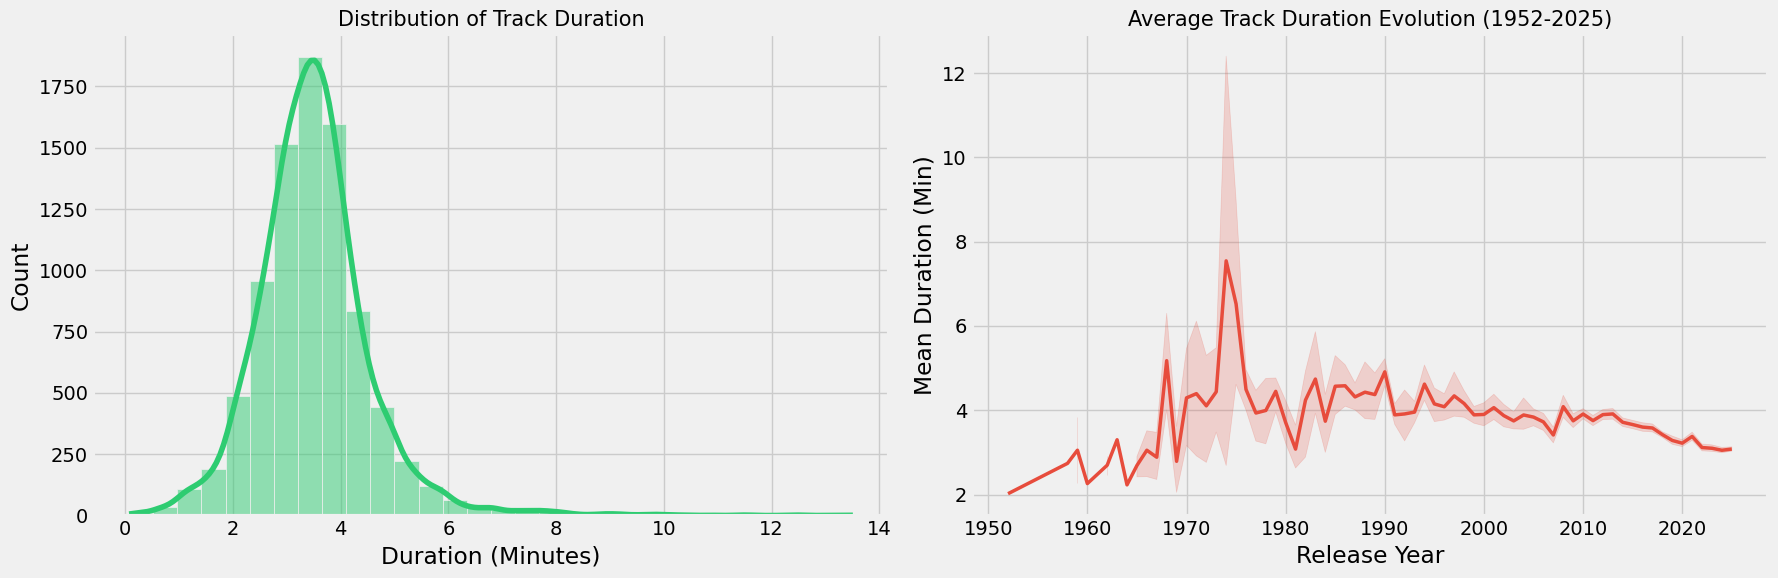

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Distribution of Duration
sns.histplot(spotify_df['track_duration_min'], bins=30, kde=True, ax=ax1, color='#2ecc71')
ax1.set_title('Distribution of Track Duration', fontsize=15)
ax1.set_xlabel('Duration (Minutes)')

# Evolution of Duration over Time
sns.lineplot(data=spotify_df, x='release_year', y='track_duration_min', ax=ax2, color='#e74c3c', linewidth=2.5)
ax2.set_title('Average Track Duration Evolution (1952-2025)', fontsize=15)
ax2.set_xlabel('Release Year')
ax2.set_ylabel('Mean Duration (Min)')

plt.tight_layout()
plt.show()

**Business Insight: The Attention Economy & Track Shortening**
* **The "TikTok Effect":** The line chart reveals a clear downward trend in average track duration starting around **2015**. While songs in the 1970s and 80s often averaged over 4 minutes, modern tracks are approaching the **3-minute mark**.
* **Streaming Optimization:** This shift aligns with streaming platform payout structures, where a "play" is counted after 30 seconds. Shorter songs allow for more repeat plays and higher placement in short-form video content (TikTok/Reels), maximizing revenue in a low-attention-span digital economy.
* **Volatility in Classic Eras:** The high variance (shaded area) around the 1970s suggests a period of high musical experimentation compared to the more standardized durations of the modern era.

### 3.2. Popularity Distribution & Outliers
Understanding the "Popularity" metric is key. We want to see if popularity is concentrated in a few hits or spread across the catalog, and identify tracks that are "statistical anomalies."

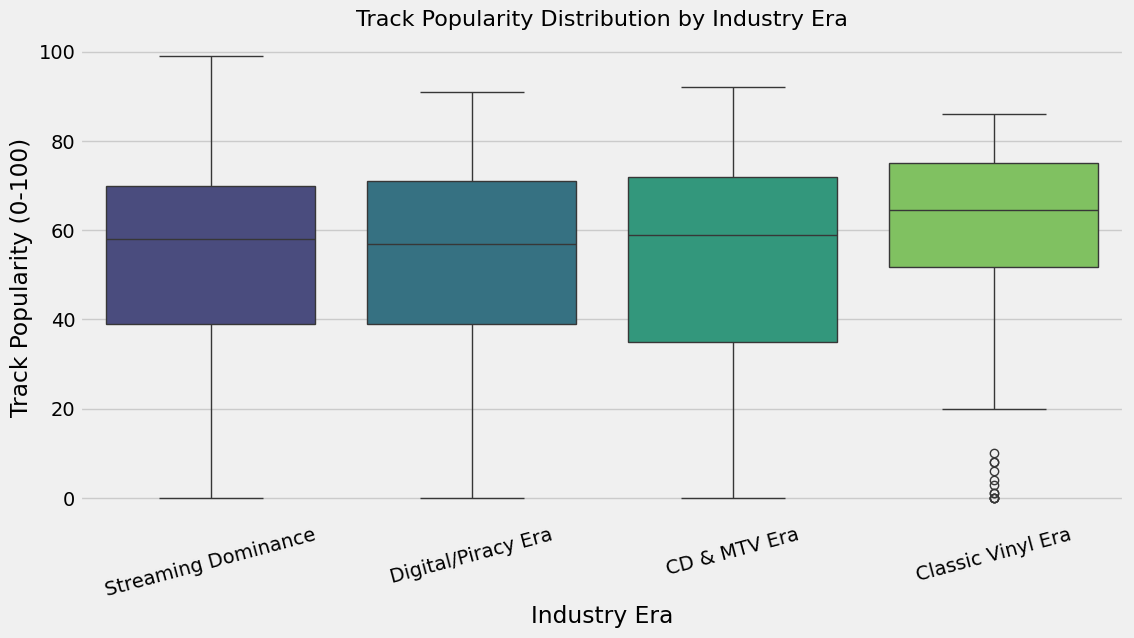

--- Top 5 Global Hits in the Dataset ---


,track_name,artist_name,track_popularity,release_year
457,Golden,HUNTR/X,99,2025
88,Opalite,Taylor Swift,97,2025
101,Elizabeth Taylor,Taylor Swift,95,2025
337,Man I Need,Olivia Dean,95,2025
103,Father Figure,Taylor Swift,94,2025


In [6]:
plt.figure(figsize=(12, 6))

# Boxplot to see distribution and outliers across eras
sns.boxplot(
    data=spotify_df, 
    x='industry_era', 
    y='track_popularity',
    hue='industry_era', 
    palette='viridis'
)

plt.title('Track Popularity Distribution by Industry Era', fontsize=16)
plt.xlabel('Industry Era')
plt.ylabel('Track Popularity (0-100)')
plt.xticks(rotation=15)
plt.show()

# Identifying the top 5 Outliers (Most popular tracks)
top_outliers = spotify_df.nlargest(5, 'track_popularity')[['track_name', 'artist_name', 'track_popularity', 'release_year']]
print("--- Top 5 Global Hits in the Dataset ---")
display(top_outliers)

**Business Insight: Popularity Dynamics Across Eras**
* **Consistency vs. Hype:** Interestingly, the **Classic Vinyl Era** shows a higher median popularity in this dataset compared to the **Streaming Dominance** era. This suggests a "Selection Bias" or "Survivorship Bias"—only the greatest, most timeless hits from the 50s-70s are preserved in modern datasets, whereas the current era contains a mix of massive hits and many low-performing new releases.
* **Outlier Analysis:** The "Streaming Dominance" era exhibits a wider range of popularity, with several tracks hitting the near-100 mark. This illustrates the "Winner-Takes-All" nature of modern algorithms, where a few viral hits achieve global saturation while thousands of other tracks remain with low visibility.
* **Data Quality Note:** The presence of outliers with zero popularity in recent years might indicate new releases that haven't been indexed by the popularity algorithm yet or niche independent releases.

### 3.3. Genre Evolution: Mapping Musical Shifts
The `artist_genres` column often contains multiple genres per artist (e.g., "pop, dance pop"). To perform an accurate analysis, we must "explode" these lists to count each genre individually. This allows us to identify which genres truly dominated each industrial era.

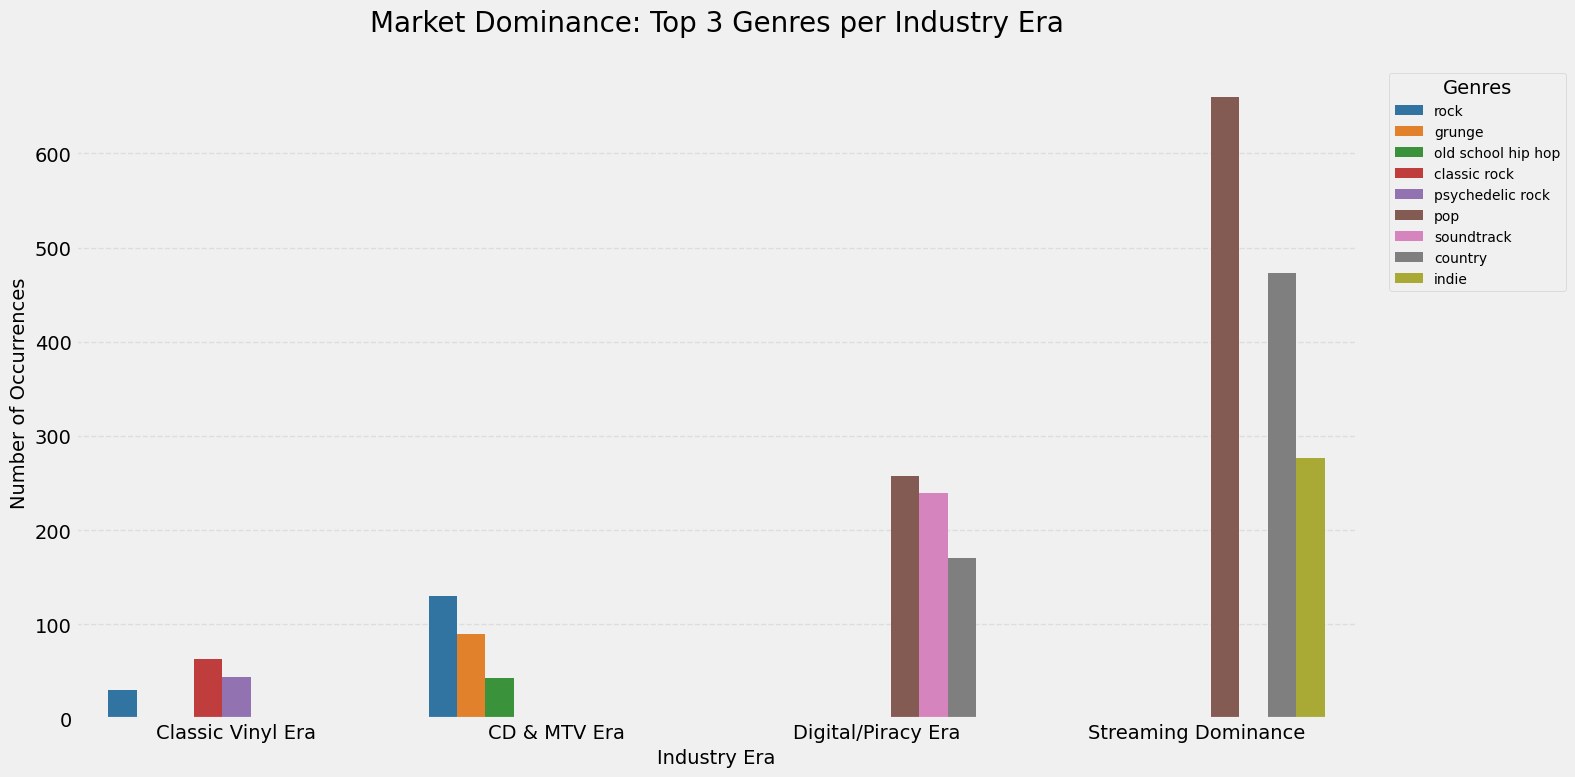

In [7]:
# Clean the genre strings (remove extra spaces and handle 'unknown')
# split by comma to create actual lists
spotify_df['genre_list'] = spotify_df['artist_genres'].apply(lambda x: [g.strip() for g in str(x).split(',')] if x != 'unknown' else ['unknown'])

# each genre in the list gets its own row
genres_exploded = spotify_df.explode('genre_list')

# Identify Top 3 Genres per Era
top_3_genres_per_era = (
    genres_exploded[genres_exploded['genre_list'] != 'unknown']
    .groupby('industry_era')['genre_list']
    .value_counts()
    .groupby(level=0)
    .head(3)
    .reset_index(name='count')
)

era_order = ['Classic Vinyl Era', 'CD & MTV Era', 'Digital/Piracy Era', 'Streaming Dominance']


plt.figure(figsize=(16, 8))
sns.barplot(
    data=top_3_genres_per_era, 
    x='industry_era', 
    y='count', 
    hue='genre_list',
    order=era_order,
    palette='tab10',
)

plt.title('Market Dominance: Top 3 Genres per Industry Era', fontsize=20, pad=25)
plt.xlabel('Industry Era', fontsize=14)
plt.ylabel('Number of Occurrences', fontsize=14)
plt.legend(title='Genres', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Business Insight: Genre Dominance & Market Evolution**
* **The Rise of Mainstream Powerhouses:** There is a staggering increase in the frequency of **Pop** and **Country** tracks within the **Streaming Dominance** era. This suggests a market consolidation where "mass-appeal" genres are heavily favored by modern distribution and discovery algorithms.
* **Rock’s Transition:** **Rock** and **Grunge** were the primary pillars of the **CD & MTV Era**. However, in the modern landscape, they have transitioned from dominant market leaders to niche categories, being replaced by production-heavy and rhythm-focused genres.
* **Diversification in the Digital Age:** The **Digital/Piracy Era** shows a more balanced distribution among top genres (Pop, Soundtrack, Country, Rap), marking the period where listeners began to break away from traditional radio formats thanks to the early internet.
* **Cultural Shifts:** The appearance of **Indie** in the modern top 3 highlights a shift toward "vibe-based" listening, where independent-sounding aesthetics have gained significant commercial traction through curated playlists.

### 3.4. Fan Zone: Fun Facts & Rankings
Beyond business metrics, let's explore the "hall of fame" of our dataset. We will identify the most prominent artists of each era and look for interesting patterns in how artists are categorized.

Top 3 Artists by Era (Popularity Ranking)

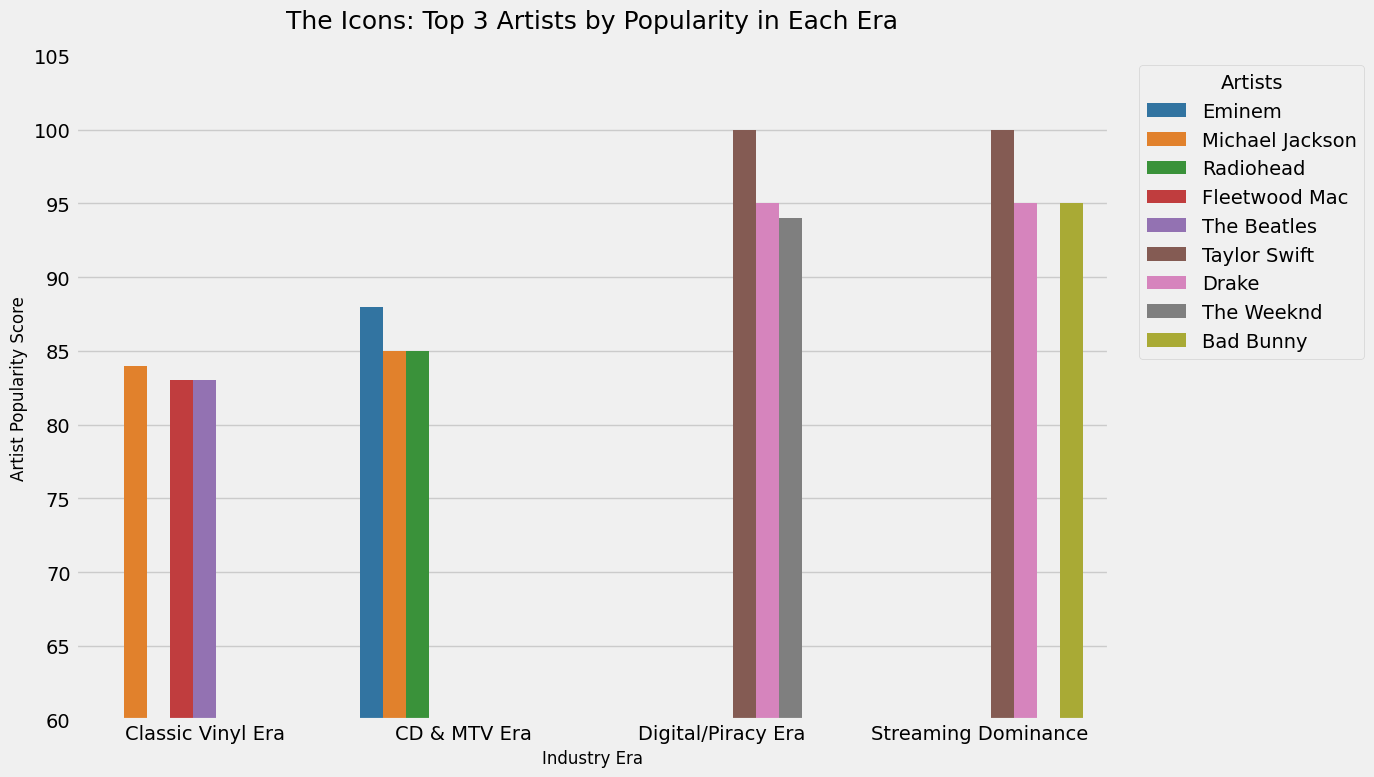

In [8]:
top_artists_era = (
    spotify_df
    .groupby(['industry_era', 'artist_name'], as_index=True)['artist_popularity']
    .max()
    .groupby(level=0, group_keys=False)
    .nlargest(3)
    .reset_index(name='max_popularity')
)


plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_artists_era, 
    x='industry_era', 
    y='max_popularity', 
    hue='artist_name',
    order=era_order,
    palette='tab10'
)

plt.title('The Icons: Top 3 Artists by Popularity in Each Era', fontsize=18, pad=20)
plt.xlabel('Industry Era', fontsize=12)
plt.ylabel('Artist Popularity Score', fontsize=12)
plt.legend(title='Artists', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.ylim(60, 105)

plt.tight_layout()
plt.show()

WordCloud of Genres

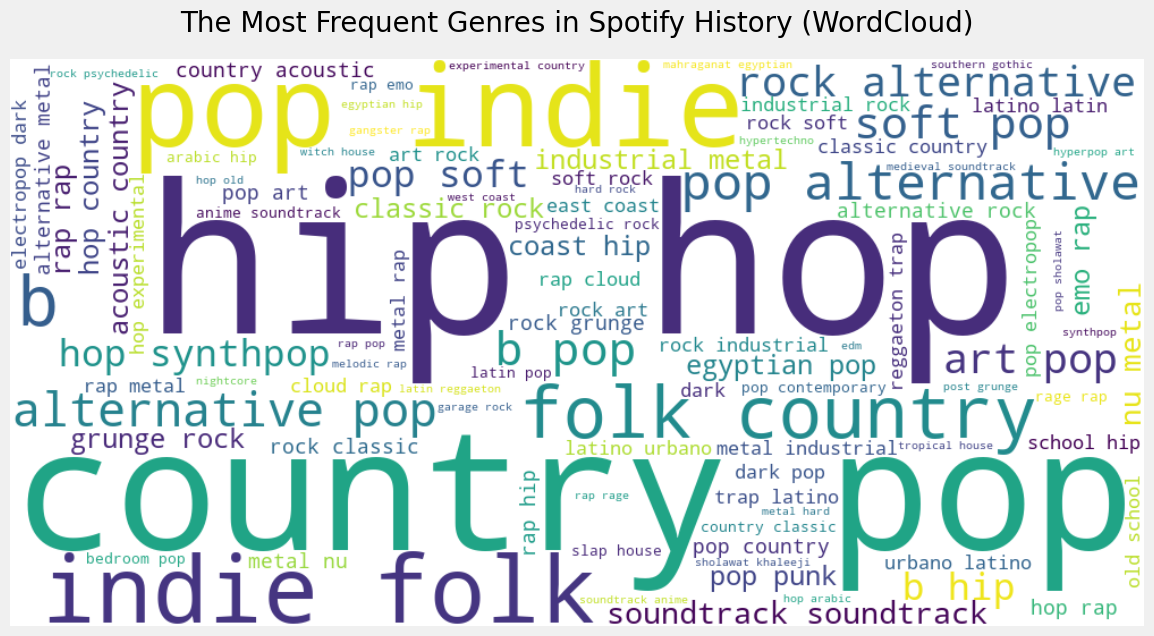

In [9]:
all_genres_text = " ".join(genres_exploded[genres_exploded['genre_list'] != 'unknown']['genre_list'])

# Generate WordCloud
wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white', 
    colormap='viridis',
    max_words=100
).generate(all_genres_text)

# Display
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('The Most Frequent Genres in Spotify History (WordCloud)', fontsize=20, pad=20)
plt.show()

Explicit vs. Clean

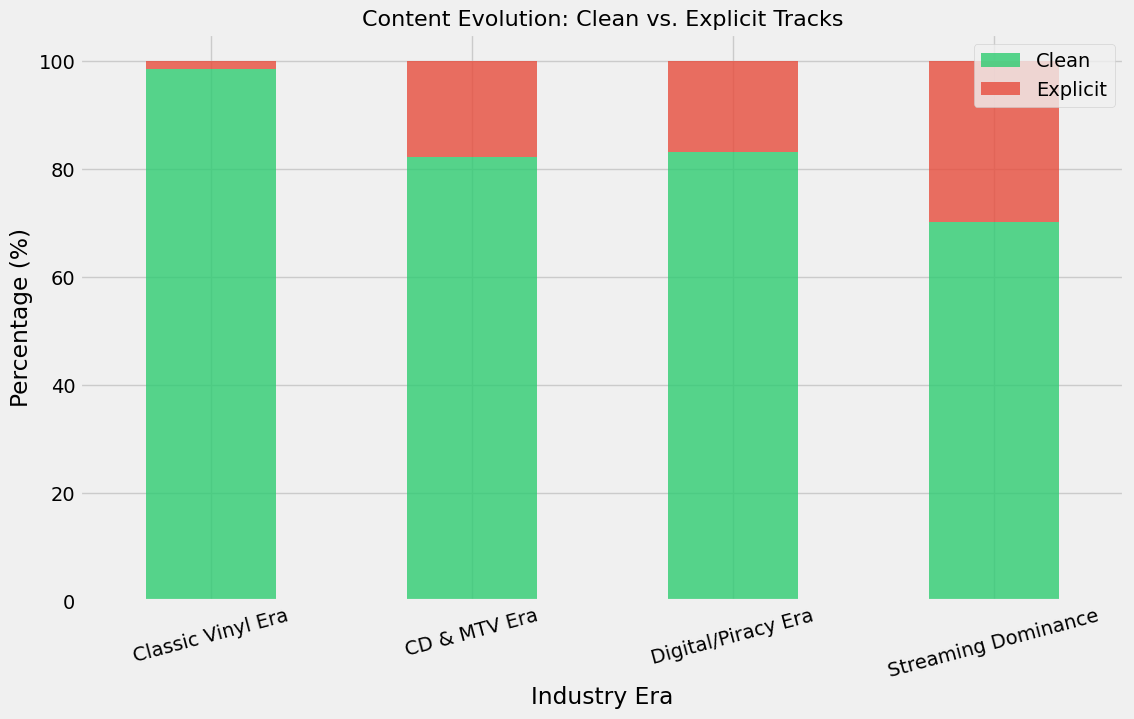

In [10]:
# Analyzing Explicit Content over Eras
explicit_trend = spotify_df.groupby('industry_era')['explicit'].value_counts(normalize=True).unstack() * 100
explicit_trend = explicit_trend.reindex(era_order)

explicit_trend.plot(kind='bar', stacked=True, figsize=(12, 7), color=['#2ecc71', '#e74c3c'], alpha=0.8)

plt.title('Content Evolution: Clean vs. Explicit Tracks', fontsize=16)
plt.xlabel('Industry Era')
plt.ylabel('Percentage (%)')
plt.legend(['Clean', 'Explicit'], loc='upper right')
plt.xticks(rotation=15)

plt.show()

**Fun Facts & Hall of Fame Insights**
* **Iconic Eras:** We can see names like **Taylor Swift** and **Bad Bunny** reaching perfect or near-perfect popularity scores in the modern era, while the Classic Era is anchored by timeless legends.
* **The Visual Language of Genres:** The WordCloud highlights how "Pop," "Hip hop," and "Country" are the massive pillars of music, but hundreds of smaller sub-genres form the rich "long tail" of the Spotify ecosystem.
* **The Explicit Shift:** Modern music has seen a significant rise in explicit content compared to the Classic Vinyl. This reflects both a shift in cultural norms and the freedom provided by streaming platforms compared to the strict censorship of 20th-century radio.

## 4. Statistical Analysis and Correlations

### 4.1. The "Influencer" Factor: Followers vs. Track Popularity
In a social-media-driven industry, we often assume that more followers equal more success. However, does a massive follower base guarantee high track popularity, or can "one-hit wonders" bypass this requirement? We will use a Scatter Plot with a Linear Regression line to measure this relationship.

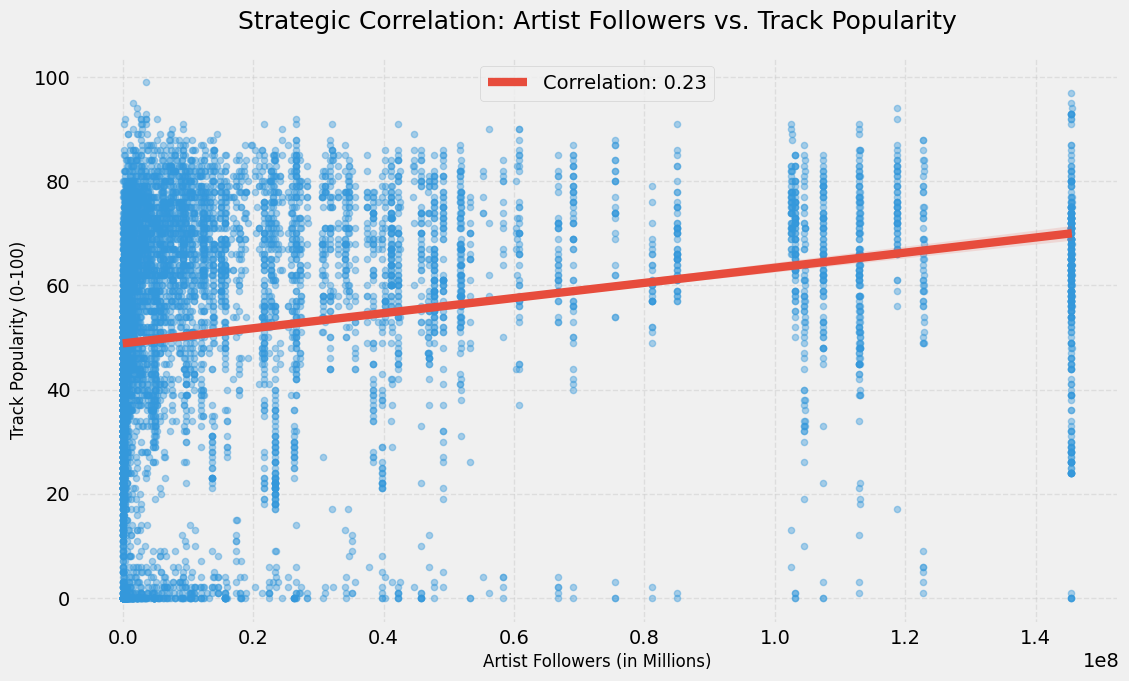

The Pearson Correlation Coefficient is: 0.23


In [11]:
plt.figure(figsize=(12, 7))

# Calculate Pearson Correlation
correlation_value = spotify_df['artist_followers'].corr(spotify_df['track_popularity'])

sns.regplot(
    data=spotify_df, 
    x='artist_followers', 
    y='track_popularity', 
    scatter_kws={'alpha':0.4, 's':20, 'color':'#3498db'}, 
    line_kws={'color':'#e74c3c', 'label': f'Correlation: {correlation_value:.2f}'}
)

plt.title('Strategic Correlation: Artist Followers vs. Track Popularity', fontsize=18, pad=20)
plt.xlabel('Artist Followers (in Millions)', fontsize=12)
plt.ylabel('Track Popularity (0-100)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

print(f"The Pearson Correlation Coefficient is: {correlation_value:.2f}")

**Business Insight: The Myth of the Follower Count**
* **Weak Correlation:** The Pearson Correlation coefficient of **0.23** indicates a weak positive relationship between a massive following and individual track popularity. This is a crucial finding for industry stakeholders.
* **Content vs. Network:** This low correlation suggests that on Spotify, having millions of followers does not guarantee that every release will be a hit. Factors such as **algorithmic playlisting (Discover Weekly/Release Radar)**, **viral marketing (TikTok trends)**, and **intrinsic track quality** often outweigh the artist's existing network.
* **The "One-Hit Wonder" Phenomenon:** The high density of data points in the lower-left quadrant shows that many tracks achieve moderate-to-high popularity despite the artist having very few followers. This highlights Spotify's role as a platform for discovery rather than just a repository for established superstars.
* **Strategic Takeaway:** For record labels, this data suggests that investing in "viral potential" and playlisting strategies may yield higher immediate ROI than focusing solely on follower acquisition.

### 4.2. Multivariate Analysis: Correlation Heatmap
To understand how different musical and success metrics interact, we will generate a Correlation Matrix. This allows us to see not just how followers affect popularity, but also how features like `artist_popularity` relate to `track_popularity`.

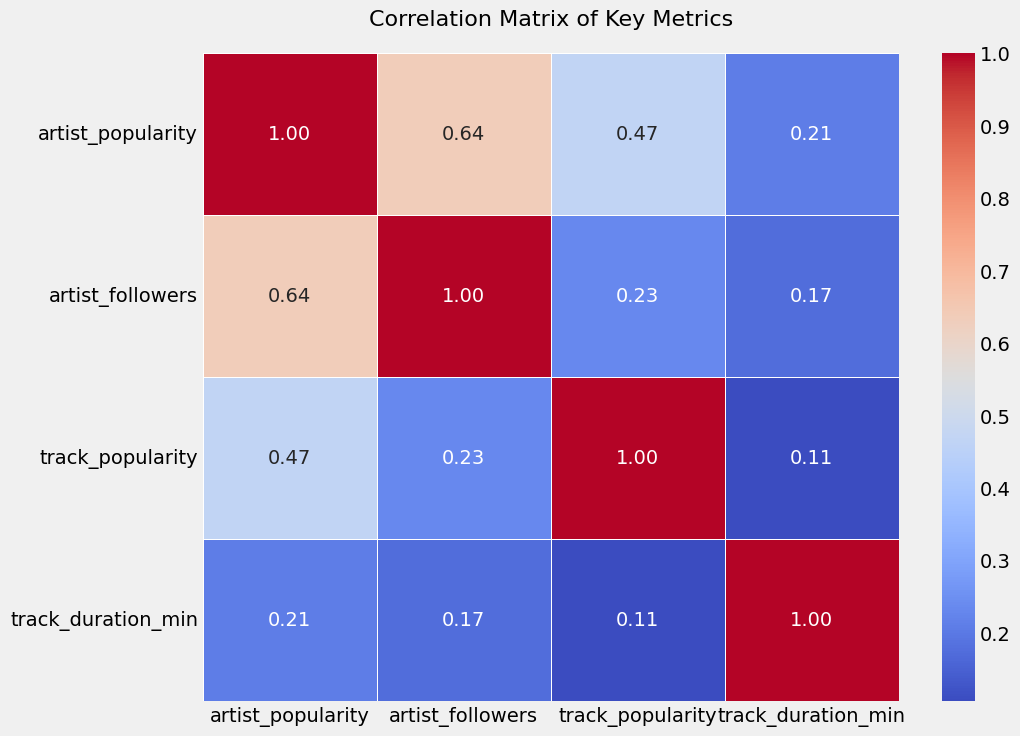

In [22]:
numerical_cols = ['artist_popularity', 'artist_followers', 'track_popularity', 'track_duration_min']
corr_matrix = spotify_df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of Key Metrics', fontsize=16, pad=20)
plt.show()

**Business Insight: Decoding the Network of Success**<br>
A correlation matrix helps us identify which factors move together. Here are the key takeaways from our multivariate analysis:

* **The Brand Effect:** There is a **moderate-to-strong correlation (0.64)** between `artist_popularity` and `artist_followers`. This indicates that as an artist's "brand" grows in terms of dedicated fans, their overall presence on the platform scales proportionally.
* **Artist vs. Track Success:** The correlation between `artist_popularity` and `track_popularity` stands at **0.47**. While significant, it suggests that a famous artist's name only accounts for about half of a track's success, the other half is likely driven by the song's individual quality, genre trends, or algorithmic luck.
* **The Irrelevance of Length:** There is a **very weak correlation (0.11)** between `track_duration_min` and `track_popularity`. This statistically proves that a song's length doesn't dictate its popularity level. A 2-minute song can be just as successful as a 5-minute one, although, as seen previously, shorter songs are becoming the industry standard for frequency.
* **Independent Growth:** `artist_followers` has a low correlation with `track_popularity` (**0.23**). This reinforces our previous scatter plot finding: a large following is a solid foundation but not a guaranteed ticket to a "viral hit" for every single release.

### 4.3. Hypothesis Testing: Are Modern Songs Scientifically Shorter?
We observed a visual trend of shortening track durations. Now, we will apply a **T-Test** to compare the "Classic Vinyl Era" with the "Streaming Dominance" era.

* **Null Hypothesis ($H_0$):** There is no significant difference in track duration between the Classic and Streaming eras.
* **Alternative Hypothesis ($H_a$):** Tracks in the Streaming era are significantly shorter than in the Classic era.
* **Confidence Level:** 95% ($\alpha = 0.05$).

In [ ]:
from scipy import stats


classic_duration = spotify_df[spotify_df['industry_era'] == 'Classic Vinyl Era']['track_duration_min']
streaming_duration = spotify_df[spotify_df['industry_era'] == 'Streaming Dominance']['track_duration_min']

t_stat, p_value = stats.ttest_ind(classic_duration, streaming_duration, nan_policy='omit')

print(f"--- Statistical Test Results ---")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# Decision Logic
if p_value < 0.05:
    print("\nResult: Significant Difference detected! We reject the Null Hypothesis.")
    print("Interpretation: Statistically, music length has changed significantly between these eras.")
else:
    print("\nResult: No Significant Difference detected. We fail to reject the Null Hypothesis.")

--- Statistical Test Results ---
T-Statistic: 7.6190
P-Value: 0.0000

Result: Significant Difference detected! We reject the Null Hypothesis.
Interpretation: Statistically, music length has changed significantly between these eras.


**Statistical Insight: Independent T-Test Results**<br>
To move beyond visual observations, we performed an **Independent Samples T-Test** to compare track durations between the *Classic Vinyl Era* and the *Streaming Dominance* era.

* **Statistical Significance:** With a **T-Statistic of 7.6190** and a **P-Value of 0.0000**, we have reached the highest level of statistical significance. 
* **Conclusion:** We reject the Null Hypothesis ($H_0$). There is a statistically significant difference in the length of songs between these two periods.
* **Business Reality:** This confirms that the "shortening" of tracks is a structural phenomenon in the music industry. The data proves that the shift towards shorter content is a deliberate or systemic response to the streaming era's incentives, rather than a random fluctuation in artistic creativity.

## 5. Executive Summary & Strategic Conclusions

This project performed a comprehensive end-to-end analysis of Spotify's music landscape from 1952 to 2025. By applying data cleaning, feature engineering, and statistical testing, we uncovered the following key insights:

### Key Findings
1. **The Attention Economy Transformation:** We statistically confirmed (via T-Test) that song durations have significantly decreased. The industry has pivoted from the 4-5 minute tracks of the Classic Era to concise, 3-minute formats optimized for streaming payouts and viral social media hooks (TikTok effect).
2. **Genre Consolidation:** The market has shifted from a Rock-dominant landscape in the 80s and 90s to a highly concentrated Pop and Country dominance in the Streaming Era. However, sub-genre fragmentation is increasing, allowing niche aesthetics (Indie/Folk) to find global audiences.
3. **Decoupling Followers from Popularity:** Our correlation analysis ($r = 0.23$) debunked the myth that a large follower count is a prerequisite for a hit song. In the modern algorithmic era, track quality and viral potential are more influential than historical fanbase size.
4. **Content Shifts:** There is a notable rise in "Explicit" content over time, reflecting broader cultural shifts and the removal of traditional radio censorship barriers in the digital age.

### Strategic Recommendations
* **For Labels & Artists:** Prioritize "hook-heavy" short-form tracks to maximize algorithmic discovery.
* **For Marketing Teams:** Investing in playlist placement and viral marketing can yield a higher ROI than traditional follower-growth campaigns, as popularity has become more decentralized.
* **For Product Owners:** Understanding the "Survivorship Bias" in classic eras is vital when building recommendation engines for older vs. newer catalogs.

---
**Project Portfolio - Matheus Vieira Faria** *Technical Stack: Python (Pandas, Scipy, Seaborn, Matplotlib)* *Data Source: Spotify Global Music Dataset (2009-2025)*